In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta, date
from dateutil.relativedelta import relativedelta
from lifelines import KaplanMeierFitter, AalenJohansenFitter
from lifelines.utils import datetimes_to_durations
from matplotlib.ticker import MultipleLocator
ruta_archivo = "C:/Users/AnaMaríaRamírezLizár/SUPERIA CAPITAL\Operacion - Credito y Riesgo - Credito y Riesgo/ADMIN INTEGRAL DE RIESGO/RIESGO DE CREDITO - RISKMATHICS\M2 - Originacion de Credito/02_Material/Base de datos.xlsx"
ruta_cierres = "C:/Users/AnaMaríaRamírezLizár/SUPERIA CAPITAL\Operacion - Credito y Riesgo - Credito y Riesgo/ADMIN INTEGRAL DE RIESGO\PORTAFOLIO MANAGMENT/Analisis/Cierre LDC.xlsx"

<>:10: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:10: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\1509542345.py:10: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  ruta_archivo = "C:/Users/AnaMaríaRamírezLizár/SUPERIA CAPITAL\Operacion - Credito y Riesgo - Credito y Riesgo/ADMIN INTEGRAL DE RIESGO/RIESGO DE CREDITO

In [2]:
data_credito = pd.read_excel(ruta_archivo, sheet_name='Creditos')
data_abonos = pd.read_excel(ruta_archivo, sheet_name='Abonos')
data_clientes = pd.read_excel(ruta_archivo, sheet_name='Clientes')
data_cierres = pd.read_excel(ruta_cierres, sheet_name='Cierres')
data_cierres = data_cierres.rename(columns={'Linea': 'Line'})

data_pm=data_clientes.loc[data_clientes['Person Type']=="MORAL",'Person Id']
dcred_pm= data_credito[data_credito['Person Id'].isin(data_pm)]
data_ldc=dcred_pm[(dcred_pm['Is line']=="SI")&(dcred_pm['Loan Status']=="AUTORIZADO")]
data_ldc=data_ldc.rename(columns={'Cosecha':'Originacion'})
data_ldc['RFC']=data_ldc['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min=dcred_pm[dcred_pm['Loan Type']=="MINISTRACION"]
data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
data_min['Status']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Status'])
data_ldc['Status']=np.where(pd.to_datetime(data_ldc['Due Date'])<pd.to_datetime(date.today()),'INACTIVO','ACTIVO')

pay=data_min[data_min['Product'].str.contains('PAY')]

C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\1364749629.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['Originacion']=data_min['Line'].map(data_ldc.set_index('Line')['Originacion'])
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\1364749629.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_min['RFC']=data_min['Person Id'].map(data_clientes.set_index('Person Id')['Taxpayer ID Number'])
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424

In [3]:
payb=data_abonos[data_abonos['Product'].str.contains('PAY')]
pay=pay.rename(columns={'Period Number':'Cuotas'})
payb=payb.rename(columns={'Installment':'Cuota'})
payb['Originacion']=payb['Portfolio Id'].map(pay.set_index('Portfolio Id')['Originacion'])
#Unificar cuotas que se pagaron por partes
pagos_agrup= (
    payb.groupby(['Portfolio Id','Cuota']).agg({'Application Date': 'max','Capital':'sum','Penalty':'sum'}).reset_index()
)
#Insertar filas por ministraciones
pay['Capital cuota']=(pay['Amount']/pay['Cuotas']).round(2)
pagos=pay.loc[pay.index.repeat(pay['Cuotas'])].assign(Cuota=lambda x: x.groupby('Portfolio Id').cumcount()+1)
pagos_agrup['Capital']=pagos_agrup['Capital'].round(2)
payc=pagos.merge(pagos_agrup,on=['Portfolio Id','Cuota'],how='left')
payc['Application Date']=np.where(payc['Product']=='PAY',np.where(payc['Capital']==payc['Capital cuota'],pd.to_datetime(payc['Application Date']),pd.to_datetime(date.today())),pd.to_datetime(payc['Application Date']))
payc['Application Date']=payc['Application Date'].fillna(pd.to_datetime(date.today()))
payc['Application Date']=pd.to_datetime(payc['Application Date'])
def fcp(row):
  duedate=pd.to_datetime(row['Opening Date'])+relativedelta(months=row['Cuota'])
  return pd.to_datetime(duedate)

payc['Fecha vencimiento cuota']=payc.apply(fcp,axis=1)
payc=payc[pd.to_datetime(payc['Fecha vencimiento cuota'])<=pd.to_datetime(date.today())]
payc['Moratorios']=payc['Penalty'].fillna(0)
def mobp1(row):
    dy=(pd.to_datetime(row['Opening Date']).year)-(pd.to_datetime(row['Originacion']).year)
    dm=(pd.to_datetime(row['Opening Date']).month)-(pd.to_datetime(row['Originacion']).month)
    MOBop=dy*12+dm+row['Cuota']
    return MOBop

payc['MOB']=payc.apply(mobp1,axis=1)

def dpdp(row):
  DPDUP= pd.to_numeric(((row['Application Date'])-row['Fecha vencimiento cuota']).days,errors='coerce')
  if DPDUP<0:
    return 0
  else:
    if row['Loan Status']=="LIQUIDADO":
      if row['Moratorios']>0:
        return DPDUP
      else:
        return 0
    else:
        return DPDUP

payc['DPD']=payc.apply(dpdp,axis=1)

def DPADP(fila):
    if fila['DPD']>0:
      return fila['Capital cuota']
    else:
      return 0

payc['mvenc']=payc.apply(DPADP,axis=1)
def propmp(fil):
  if fil['Amount']==0:
    return 0
  else:
    return fil['mvenc']/fil['Amount']

fi=pd.to_datetime(input("Desde qué fecha deseas analizar: "))
ff=pd.to_datetime(input("Hasta qué fecha deseas analizar: "))
filtrop=payc[(payc['Originacion']>=fi) & (payc['Originacion']<=ff)]
sit_vencp=pd.pivot_table(
    filtrop,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['mvenc'],
    aggfunc='sum'
)

filtro_monp=data_ldc[(data_ldc['Product'].str.contains('PAY')) & (data_ldc['Originacion']>=fi) & (data_ldc['Originacion']<=ff)]
sit_monp=pd.pivot_table(
    filtro_monp,
    index=pd.Grouper(key='Originacion',freq='1M'),
    values=['Amount'],
    aggfunc='sum'
)


sitp=pd.merge(sit_vencp,sit_monp,on='Originacion')

sit_vencp=sit_vencp.reset_index()
sit_monp=sit_monp.reset_index()

sitp['Indice']=sitp.apply(propmp,axis=1)


coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
coh_datap=coh_datap.reset_index()

coh_morap=coh_datap.pivot_table(
                              index='Originacion',
                              columns='MOB',
                              values='mvenc')


coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])['Amount'].apply(np.sum)
coh_desp=coh_desp.reset_index()

coh_count_desp =coh_desp.pivot_table(
                              index=pd.Grouper(key="Originacion",freq='1M'),
                              values='Amount')



#indicadores de columnas
indcp=coh_morap.divide(coh_count_desp.iloc[:,0],axis=0)
indcp=(indcp*100).round(4).dropna(how='all')
indcp.index=indcp.index.strftime('%Y-%m')
#indc=indc.fillna(0)

C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\918693284.py:65: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\918693284.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.Grouper(key='Originacion',freq='1M'),
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\918693284.py:87: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_datap=filtrop.groupby([pd.Grouper(key='Originacion',freq='1M'),'MOB'])['mvenc'].apply(np.sum)
C:\Users\AnaMaríaRamírezLizár\AppData\Local\Temp\ipykernel_21424\918693284.py:96: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  coh_desp=filtro_monp.groupby([pd.Grouper(key='Originacion',freq='1M')])['Amo

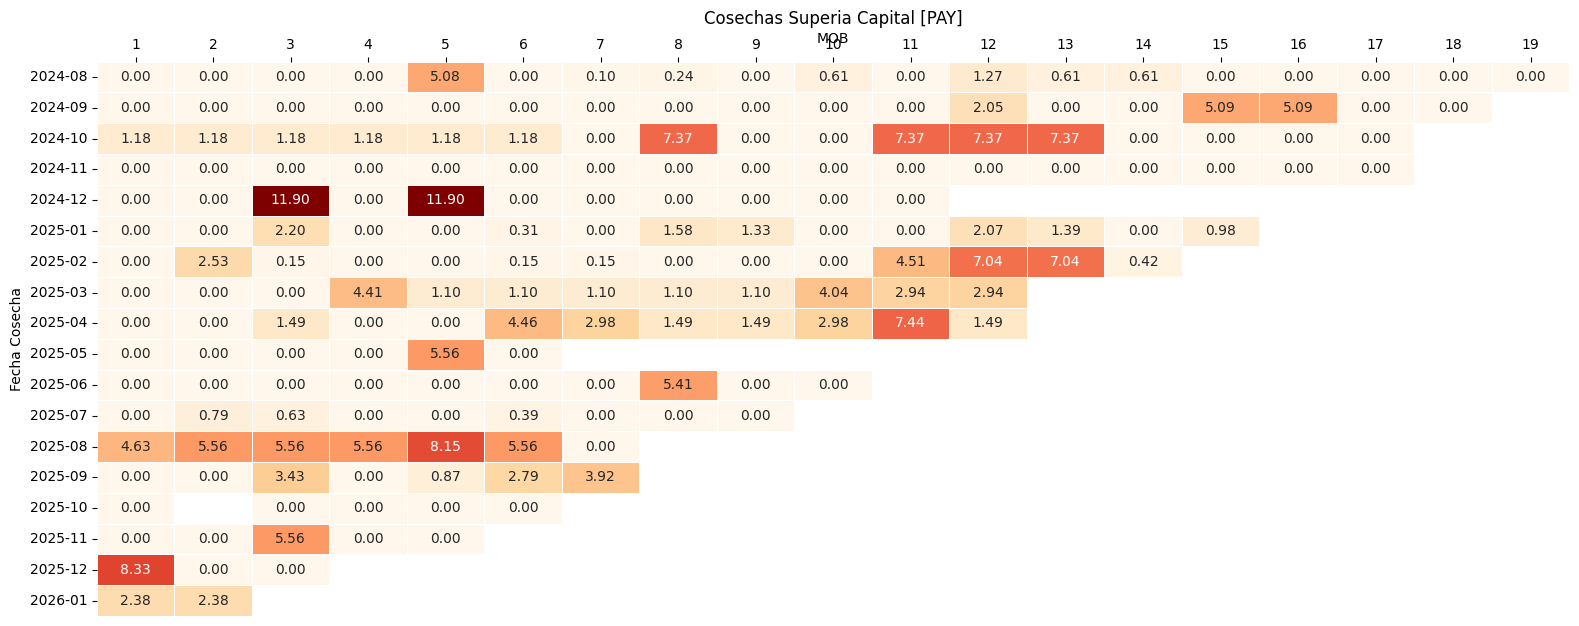

In [4]:
rows,cols=indcp.shape #Para ajuste de tamaño
plt.figure(figsize=(cols*1,rows*0.4))
ax=sns.heatmap(indcp,annot= True,cmap="OrRd",fmt='.2f',linewidths=.5,cbar=False)
ax.xaxis.tick_top()
ax.xaxis.label_position='top'
ax.set(title='Cosechas Superia Capital [PAY]',ylabel='Fecha Cosecha')
plt.show()